# Part One

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
knn = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:")
print(cm)

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9298245614035088

Confusion Matrix:
[[38  4]
 [ 4 68]]

Precision: 0.9444444444444444
Recall: 0.9444444444444444
F1-score: 0.9444444444444444


# Part **Two**

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
knn_scaled = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = knn_scaled.predict(X_test_scaled)

In [ ]:
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
cm_scaled = confusion_matrix(y_test, y_pred_scaled)
precision_scaled = precision_score(y_test, y_pred_scaled)
recall_scaled = recall_score(y_test, y_pred_scaled)
f1_scaled = f1_score(y_test, y_pred_scaled)

print("Accuracy:", accuracy_scaled)

print("\nConfusion Matrix:")
print(cm_scaled)

print("\nPrecision:", precision_scaled)
print("Recall:", recall_scaled)
print("F1-score:", f1_scaled)

Accuracy: 0.9824561403508771

Confusion Matrix:
[[40  2]
 [ 0 72]]

Precision: 0.972972972972973
Recall: 1.0
F1-score: 0.9863013698630136


# Compare Part 1 vs Part **2**

In [ ]:
print("Accuracy before scaling:", accuracy)
print("Accuracy after scaling:", accuracy_scaled)

if accuracy_scaled > accuracy:
    print("Accuracy improved after scaling.")
elif accuracy_scaled < accuracy:
    print("Accuracy decreased after scaling.")
else:
    print("Accuracy stayed the same.")

Accuracy before scaling: 0.9298245614035088
Accuracy after scaling: 0.9824561403508771
Accuracy improved after scaling.


Questions for Part 2

1. Did accuracy improve?

yes based on the results

2. Why is scaling important for KNN?

KNN is based on distance. If features have very different ranges, features with larger numerical values can contribute much more to the distance than features with smaller values. StandardScaler puts the features on a comparable scale.

3. Which feature dominates the distance calculation before scaling?



In [ ]:
#question three answer
feature_ranges = pd.DataFrame({
    "Feature": data.feature_names,
    "Min": X.min(axis=0),
    "Max": X.max(axis=0),
    "Range": X.max(axis=0) - X.min(axis=0)
})

feature_ranges.sort_values("Range", ascending=False).head(10)

,Feature,Min,Max,Range
23,worst area,185.200,4254.00,4068.800
3,mean area,143.500,2501.00,2357.500
13,area error,6.802,542.20,535.398
22,worst perimeter,50.410,251.20,200.790
2,mean perimeter,43.790,188.50,144.710
21,worst texture,12.020,49.54,37.520
1,mean texture,9.710,39.28,29.570
20,worst radius,7.930,36.04,28.110
12,perimeter error,0.757,21.98,21.223
0,mean radius,6.981,28.11,21.129


worst area dominates the distance calculation because it has the largest numerical range:

Minimum = 185.2
Maximum = 4254.0
Range = 4068.8

# Part **Three**

In [ ]:
knn_manhattan = KNeighborsClassifier(
    n_neighbors=3,
    metric="manhattan"
)

knn_manhattan.fit(X_train_scaled, y_train)

y_pred_manhattan = knn_manhattan.predict(X_test_scaled)

accuracy_manhattan = accuracy_score(y_test, y_pred_manhattan)
f1_manhattan = f1_score(y_test, y_pred_manhattan)

print("Mcanhattan Accuracy:", accuracy_manhattan)
print("Manhattan F1-score:", f1_manhattan)

Mcanhattan Accuracy: 0.9649122807017544
Manhattan F1-score: 0.9726027397260274


compare f1 and accuracy of manhattan distance and euclidean and fill the tabel
and Which metric performs best and why?


# Part **Four**

In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 15, 21]

accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

for k, acc in zip(k_values, accuracies):
    print(f"K = {k}: Accuracy = {acc:.4f}")

K = 1: Accuracy = 0.9386
K = 3: Accuracy = 0.9825
K = 5: Accuracy = 0.9561
K = 7: Accuracy = 0.9737
K = 9: Accuracy = 0.9737
K = 11: Accuracy = 0.9737
K = 15: Accuracy = 0.9737
K = 21: Accuracy = 0.9649


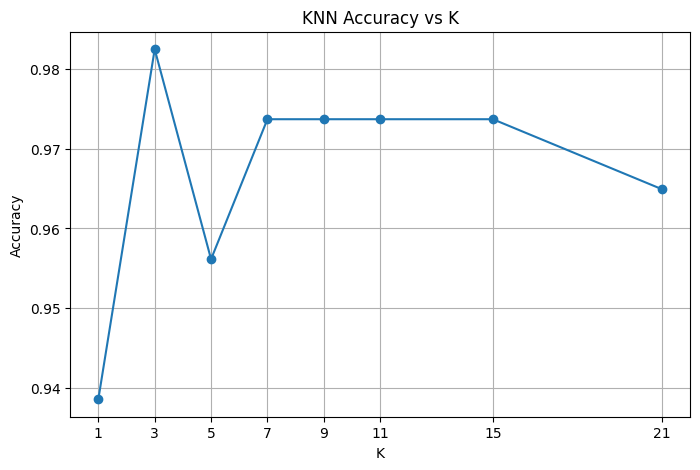

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")

plt.xticks(k_values)
plt.grid(True)

plt.show()

Does K=1 often overfit?
K=1 can often overfit because it relies on only one nearest neighbor and is sensitive to individual training samples and noise. In our experiment, K=1 achieved 93.86% accuracy, while K=3 achieved a higher accuracy of 98.25%, suggesting that K=1 was not the best choice for this dataset.

Does very large K underfit?
Yes, a very large K can cause underfitting because the model considers too many neighbors and becomes less sensitive to local patterns in the data. In our experiment, K=21 achieved 96.49% accuracy, which was lower than the best accuracy of 98.25% obtained with K=3.

# Part Five

In [ ]:
np.random.seed(42)

noise_features = np.random.rand(X.shape[0], 100)

print("Noise shape:", noise_features.shape)

Noise shape: (569, 100)


In [ ]:
X_with_noise = np.hstack((X, noise_features))

print("Original shape:", X.shape)
print("New shape:", X_with_noise.shape)

Original shape: (569, 30)
New shape: (569, 130)


Split the new dataset

In [ ]:
X_train_noise, X_test_noise, y_train_noise, y_test_noise = train_test_split(
    X_with_noise,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler_noise = StandardScaler()

X_train_noise_scaled = scaler_noise.fit_transform(X_train_noise)
X_test_noise_scaled = scaler_noise.transform(X_test_noise)

In [ ]:
knn_noise = KNeighborsClassifier(
    n_neighbors=3,
    metric="euclidean"
)

knn_noise.fit(X_train_noise_scaled, y_train_noise)

y_pred_noise = knn_noise.predict(X_test_noise_scaled)

In [ ]:
accuracy_noise = accuracy_score(y_test_noise, y_pred_noise)
f1_noise = f1_score(y_test_noise, y_pred_noise)

print("Accuracy with noise:", accuracy_noise)
print("F1-score with noise:", f1_noise)

Accuracy with noise: 0.9035087719298246
F1-score with noise: 0.9230769230769231


In [ ]:
print("Original Accuracy:", accuracy_scaled)
print("Accuracy with 100 noise features:", accuracy_noise)

print("\nOriginal F1:", f1_scaled)
print("F1 with 100 noise features:", f1_noise)

Original Accuracy: 0.9824561403508771
Accuracy with 100 noise features: 0.9035087719298246

Original F1: 0.9863013698630136
F1 with 100 noise features: 0.9230769230769231


What happened?

After adding 100 noise features, the accuracy dropped from 98.25% to 90.35%, and the F1-score dropped from 98.63% to 92.31%.

Why?

The added features were irrelevant noise, so they made it harder for the model to identify the important patterns and increased the risk of overfitting.

Curse of Dimensionality

The Curse of Dimensionality occurs when increasing the number of features makes learning more difficult. With many irrelevant dimensions, the data becomes more complex and sparse, reducing the model's ability to generalize and causing lower performance.